In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('database/flights.csv', low_memory=False)
df['DELAYED'] = np.where(df['ARRIVAL_DELAY'] >= 15,1,0)

In [3]:
cols = df.columns.tolist()
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED,PERIOD
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [4]:
df = df[df['CANCELLED'] == 0] #removing cancelled flights
df = df[df['DIVERTED'] == 0]  #removing diverted flights

In [ ]:
def show_stats(df):
    columns = df.columns.tolist()

    for i in range(len(columns)):
        print('col: ', columns[i], ' nunique: ', df[columns[i]].nunique(), '    total data: ', df[columns[i]].count(), '  nans: ', df[columns[i]].isna().sum())


In [6]:
show_stats(df)

col:  YEAR  nunique:  1     total data:  5714008   nans:  0
col:  MONTH  nunique:  12     total data:  5714008   nans:  0
col:  DAY  nunique:  31     total data:  5714008   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  5714008   nans:  0
col:  AIRLINE  nunique:  14     total data:  5714008   nans:  0
col:  FLIGHT_NUMBER  nunique:  6946     total data:  5714008   nans:  0
col:  TAIL_NUMBER  nunique:  4896     total data:  5714008   nans:  0
col:  ORIGIN_AIRPORT  nunique:  628     total data:  5714008   nans:  0
col:  DESTINATION_AIRPORT  nunique:  629     total data:  5714008   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1320     total data:  5714008   nans:  0
col:  DEPARTURE_TIME  nunique:  1440     total data:  5714008   nans:  0
col:  DEPARTURE_DELAY  nunique:  1212     total data:  5714008   nans:  0
col:  TAXI_OUT  nunique:  184     total data:  5714008   nans:  0
col:  WHEELS_OFF  nunique:  1440     total data:  5714008   nans:  0
col:  SCHEDULED_TIME  nunique:  549 

In [30]:
wanted_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
    'DELAYED'
    
]

filtered_df = df[wanted_cols]

In [31]:

filtered_df

,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,SCHEDULED_ARRIVAL,DELAYED
0,1,4,AS,ANC,SEA,5,1448,430,0
1,1,4,AA,LAX,PBI,10,2330,750,0
2,1,4,US,SFO,CLT,20,2296,806,0
3,1,4,AA,LAX,MIA,20,2342,805,0
4,1,4,AS,SEA,ANC,25,1448,320,0
...,...,...,...,...,...,...,...,...,...
5819074,12,4,B6,LAX,BOS,2359,2611,819,0
5819075,12,4,B6,JFK,PSE,2359,1617,446,0
5819076,12,4,B6,JFK,SJU,2359,1598,440,0
5819077,12,4,B6,MCO,SJU,2359,1189,340,0


In [32]:
def create_filtered_sample(filtered_df):
    filtered_df_sample = filtered_df.sample(frac=0.02, random_state=42)
    # df_sample = df.sample(frac=0.02, random_state=42)
    show_stats(filtered_df_sample)
    return filtered_df_sample

In [33]:
def compare(df, col1, col2):

    def_graph = df.groupby(col1)[col2].mean().reset_index()

    # 2. Plotar
    plt.bar(def_graph[col1], def_graph[col2], color='skyblue')

    # Customização
    plt.title(f'{col2} x {col1}')
    plt.xlabel(col1)
    plt.ylabel(f'{col2} mean')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

In [34]:
def hour_to_sec(df, col):
    data = df[col]
    hours = data // 100
    mins = data % 100
    df[col] = (hours * 3600) + (mins * 60)

def min_to_sec(df, col):
    df[col] = df[col]*60



In [35]:
filtered_df_sample = create_filtered_sample(filtered_df)

hours_to_transform = [
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL'
]

mins_to_transform = [
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'ELAPSED_TIME',
    'AIR_TIME',
    'TAXI_IN',
    'ARRIVAL_DELAY'
]

for col in hours_to_transform:
    hour_to_sec(filtered_df_sample, col)

# for col in mins_to_transform:
#     min_to_sec(filtered_df_sample, col)

filtered_df_sample

col:  MONTH  nunique:  12     total data:  114280   nans:  0
col:  DAY_OF_WEEK  nunique:  7     total data:  114280   nans:  0
col:  AIRLINE  nunique:  14     total data:  114280   nans:  0
col:  ORIGIN_AIRPORT  nunique:  586     total data:  114280   nans:  0
col:  DESTINATION_AIRPORT  nunique:  588     total data:  114280   nans:  0
col:  SCHEDULED_DEPARTURE  nunique:  1234     total data:  114280   nans:  0
col:  DISTANCE  nunique:  1304     total data:  114280   nans:  0
col:  SCHEDULED_ARRIVAL  nunique:  1336     total data:  114280   nans:  0
col:  DELAYED  nunique:  2     total data:  114280   nans:  0


,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,SCHEDULED_ARRIVAL,DELAYED
3335058,7,1,OO,CVG,MKE,58980,318,59880,0
4857110,10,5,DL,13204,12953,66180,950,76080,0
4454180,10,1,WN,13796,14747,42600,672,49500,0
5132772,11,2,DL,ATL,SAV,47100,214,50820,0
4075015,9,5,OO,GEG,SEA,21600,224,25200,0
...,...,...,...,...,...,...,...,...,...
1282928,3,2,OO,IAH,CVG,56100,871,67920,1
3349673,7,2,NK,ORD,ATL,49320,606,60120,0
5350571,12,2,DL,DEN,DTW,58500,1123,75660,0
1566498,4,5,UA,IAD,IAH,79260,1190,720,0


In [36]:
# Definindo os limites em segundos
# 0 a 43199: MORNING
# 43200 a 64799: AFTERNOON
# 64800 a 86400: EVENING
bins = [0, 43200, 64800, 86400]
labels = ['MORNING', 'AFTERNOON', 'EVENING']

# Criando a nova coluna PERIOD baseada na sua coluna de segundos
# Substitua 'SCHEDULED_DEPARTURE_SECONDS' pelo nome exato da sua coluna
filtered_df_sample['PERIOD'] = pd.cut(
    filtered_df_sample['SCHEDULED_DEPARTURE'], 
    bins=bins, 
    labels=labels, 
    right=False, # Garante que 12h (43200) caia em AFTERNOON
    include_lowest=True
)

# Visualizando a distribuição para validar o insight (Requisito de EDA)
print(filtered_df_sample.groupby('PERIOD')['DELAYED'].mean())

# Lógica para o Hemisfério Norte
# Inverno: Dez(12), Jan(1), Fev(2)
# Primavera: Mar(3), Abr(4), Mai(5)
# Verão: Jun(6), Jul(7), Ago(8)
# Outono: Set(9), Out(10), Nov(11)

season_map = {
    12: 'WINTER', 1: 'WINTER', 2: 'WINTER',
    3: 'SPRING', 4: 'SPRING', 5: 'SPRING',
    6: 'SUMMER', 7: 'SUMMER', 8: 'SUMMER',
    9: 'FALL', 10: 'FALL', 11: 'FALL'
}

filtered_df_sample['SEASON'] = filtered_df_sample['MONTH'].map(season_map)

# Meses com feriados de alto impacto na malha aérea dos EUA:
# 1: New Year / MLK Day
# 5: Memorial Day
# 7: Independence Day
# 11: Thanksgiving
# 12: Christmas

holiday_months = [1, 5, 7, 11, 12]

filtered_df_sample['HOLIDAY'] = filtered_df_sample['MONTH'].isin(holiday_months).astype(int)

PERIOD
MORNING      0.128926
AFTERNOON    0.208659
EVENING      0.251802
Name: DELAYED, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from category_encoders import TargetEncoder

In [38]:
target = ['DELAYED']
features = list(set(filtered_df_sample.columns) - set(target))
features

['PERIOD',
 'DESTINATION_AIRPORT',
 'SEASON',
 'SCHEDULED_ARRIVAL',
 'MONTH',
 'SCHEDULED_DEPARTURE',
 'DAY_OF_WEEK',
 'AIRLINE',
 'DISTANCE',
 'HOLIDAY',
 'ORIGIN_AIRPORT']

In [39]:
# 1. Seleção de Features (evitando data leakage)
target = ['DELAYED']
features = list(set(filtered_df_sample.columns) - set(target))


X = filtered_df_sample[features]
y = filtered_df_sample[target]


# 2. Divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Aplicando Target Encoding nas colunas categóricas
encoder = TargetEncoder(cols=['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'PERIOD', 'HOLIDAY', 'SEASON'], smoothing=20.0)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [52]:
# Inicializando o modelo
# n_jobs=-1 usa todos os núcleos do seu i7 para acelerar o treino
model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=15, 
                                  random_state=42,
                                  class_weight='balanced', 
                                  n_jobs=-1)

# Treinando
model_rf.fit(X_train_encoded, y_train)

# Predições
y_pred = model_rf.predict(X_test_encoded)
y_proba = model_rf.predict_proba(X_test_encoded)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusão para entender Falsos Positivos e Falsos Negativos
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(conf_matrix)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.85      0.81      0.83     27941
           1       0.31      0.39      0.34      6343

    accuracy                           0.73     34284
   macro avg       0.58      0.60      0.59     34284
weighted avg       0.75      0.73      0.74     34284

ROC-AUC Score: 0.6484

Matriz de Confusão:
[[22515  5426]
 [ 3891  2452]]


In [41]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from category_encoders import TargetEncoder


# 1. Preparação dos dados
features = ['MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 
            'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DISTANCE', 'SCHEDULED_ARRIVAL']
target = 'DELAYED'

X = filtered_df_sample[features]
y = filtered_df_sample[target]

# Divisão treino e teste (mantendo a proporção com stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Target Encoding (mesma lógica usada no Random Forest para comparação justa)
encoder = TargetEncoder(cols=['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], smoothing=20.0)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

# 3. Cálculo do peso para balanceamento
# ratio = total_negativos / total_positivos
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 4. Treinamento do XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # Corrige o problema do recall baixo
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' # Acelera o treino em datasets grandes
)

model_xgb.fit(X_train_encoded, y_train)

# 5. Predições e Avaliação
y_pred_xgb = model_xgb.predict(X_test_encoded)
y_proba_xgb = model_xgb.predict_proba(X_test_encoded)[:, 1]

print("--- Relatório de Classificação: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

c:\Users\Pedro\OneDrive\Documentos\PosTech_ML_Eng\Fase_3_Arq_ML\TC_3\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:40:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Relatório de Classificação: XGBoost ---
              precision    recall  f1-score   support

           0       0.88      0.62      0.73     27941
           1       0.27      0.61      0.37      6343

    accuracy                           0.62     34284
   macro avg       0.57      0.62      0.55     34284
weighted avg       0.76      0.62      0.66     34284

ROC-AUC Score: 0.6596

Matriz de Confusão:
[[17402 10539]
 [ 2470  3873]]


In [42]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Definindo o modelo base
# tree_method='hist' é essencial para velocidade com muitos dados
xgb_base = XGBClassifier(
    n_estimators=50, # Reduzido para o GridSearch rodar mais rápido
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' 
)

# Definindo a grade de parâmetros
# Testaremos variações em torno do seu 'ratio' atual e profundidade
param_grid = {
    'max_depth': [4, 6, 8],
    'scale_pos_weight': [ratio * 0.8, ratio, ratio * 1.2],
    'subsample': [0.8] # Ajuda a evitar overfitting
}

# Configurando o GridSearchCV
# scoring='f1' foca no equilíbrio que você precisa para a classe 1
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1', 
    cv=3,          # 3-fold para não demorar horas
    verbose=2,
    n_jobs=-1      # Usa todos os núcleos do seu i7
)

# Executando o ajuste
grid_search.fit(X_train_encoded, y_train)

# Melhores parâmetros encontrados
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score no Treino: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\Pedro\OneDrive\Documentos\PosTech_ML_Eng\Fase_3_Arq_ML\TC_3\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:41:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores parâmetros: {'max_depth': 6, 'scale_pos_weight': np.float64(4.4051351351351355), 'subsample': 0.8}
Melhor F1-Score no Treino: 0.3750


In [43]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_encoded)

print("\n--- Relatório Final: XGBoost Otimizado ---")
print(classification_report(y_test, y_pred_best))


--- Relatório Final: XGBoost Otimizado ---
              precision    recall  f1-score   support

           0       0.87      0.61      0.72     27941
           1       0.26      0.62      0.37      6343

    accuracy                           0.61     34284
   macro avg       0.57      0.61      0.54     34284
weighted avg       0.76      0.61      0.65     34284



In [44]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Agregando dados por aeroporto de origem
airport_stats = filtered_df_sample.groupby('ORIGIN_AIRPORT').agg({
    'DELAYED': 'mean',        # Taxa de atraso
    'DISTANCE': 'mean',       # Distância média dos voos
    'SCHEDULED_DEPARTURE': 'count' # Volume de voos (importante para escala)
}).rename(columns={'SCHEDULED_DEPARTURE': 'FLIGHT_COUNT'})

# Normalização (Essencial para K-Means)
scaler = StandardScaler()
airport_stats_scaled = scaler.fit_transform(airport_stats)

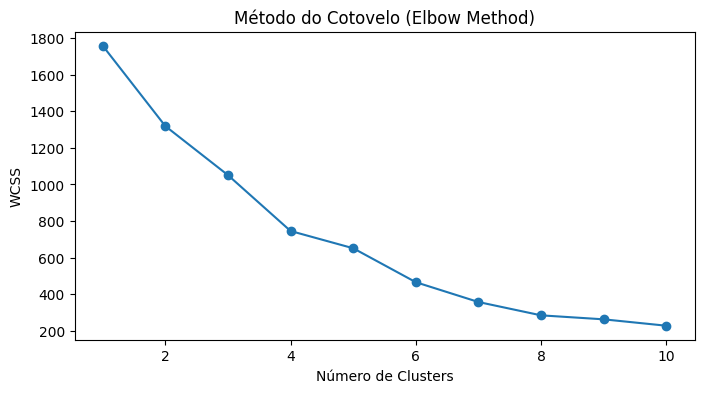

In [45]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(airport_stats_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

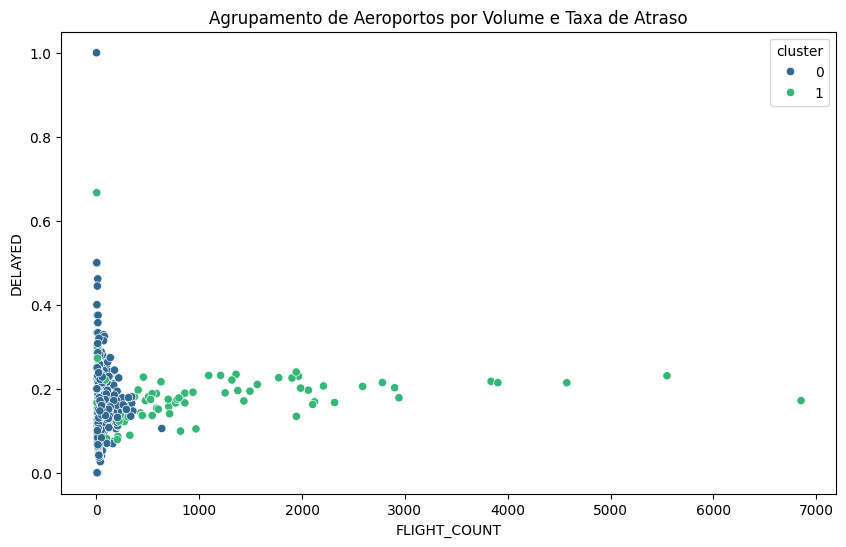

In [46]:
# Aplicando K-Means com 4 clusters (exemplo)
kmeans = KMeans(n_clusters=2, random_state=42)
airport_stats['cluster'] = kmeans.fit_transform(airport_stats_scaled).argmax(axis=1) # Simplificação para atribuição

# Visualização: Taxa de Atraso vs. Volume de Voos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airport_stats, x='FLIGHT_COUNT', y='DELAYED', hue='cluster', palette='viridis')
plt.title('Agrupamento de Aeroportos por Volume e Taxa de Atraso')
plt.show()

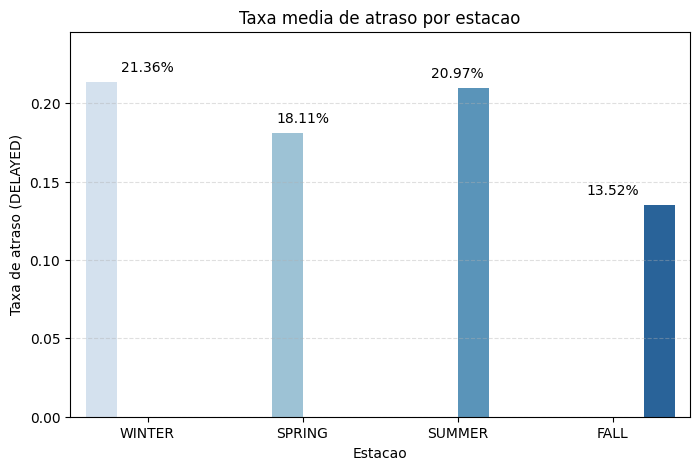

In [53]:
# Grafico: season x delayed (taxa media de atraso por estacao)
season_delay = (filtered_df_sample.groupby('SEASON', as_index=False)['DELAYED'].mean().rename(columns={'DELAYED': 'DELAY_RATE'}))

season_order = ['WINTER', 'SPRING', 'SUMMER', 'FALL']
season_delay['SEASON'] = pd.Categorical(
    season_delay['SEASON'], categories=season_order, ordered=True
)
season_delay = season_delay.sort_values('SEASON')

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=season_delay,
    x='SEASON',
    y='DELAY_RATE',
    hue='SEASON',
    palette='Blues',
    legend=False
)

plt.title('Taxa media de atraso por estacao')
plt.xlabel('Estacao')
plt.ylabel('Taxa de atraso (DELAYED)')
plt.ylim(0, season_delay['DELAY_RATE'].max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(season_delay['DELAY_RATE']):
    ax.text(i, value + 0.005, f'{value:.2%}', ha='center', va='bottom')

plt.show()